# KUL H02A5a — Group Assignment 1: Features & Classification

**Team 27** | Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos

---

This notebook starts **after face crops have already been extracted** (by `face_detection.py`).  
It covers three sections:

| Section | Content |
|---------|---------|
| 1 | HOG feature extraction & visualisation |
| 2 | PCA / Eigenface extraction & visualisation |
| 3 | Classification — pipeline, scaling, multiple models |

> **Assumption:** `train_X_final.npy`, `train_y_final.npy`, and `test_X.npy` exist in the  
> `final_train_extracted_faces/` directory (produced by the preprocessing notebook).


## Imports & setup

In [1]:
import os, sys, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.metrics         import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.svm             import SVC, LinearSVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neural_network  import MLPClassifier
from skimage.feature         import hog
warnings.filterwarnings('ignore')

# Add local modules if running on Kaggle (dataset attached) or locally
try:
    sys.path.insert(0, '/kaggle/input/cv-group27-modules/')
    from preprocessing import face_to_gray, convert_crops_to_gray, flatten_images, normalize_per_image
    from visualize     import plot_tsne, plot_confusion_matrix, plot_class_distribution
    print("Loaded helper modules from Kaggle dataset.")
except ImportError:
    # Running locally — modules are in the working directory
    from preprocessing import face_to_gray, convert_crops_to_gray, flatten_images, normalize_per_image
    from visualize     import plot_tsne, plot_confusion_matrix, plot_class_distribution
    print("Loaded helper modules from local directory.")

# ── Constants ─────────────────────────────────────────────────────────────────
FACE_SIZE   = (100, 100)   # raw crop size from face_detection
TARGET_SIZE = (64, 64)     # resize target for HOG / PCA input
CLASS_NAMES = {0: 'Michael/Sarah', 1: 'Jesse', 2: 'Mila'}
CLASS_COLORS = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
DATA_DIR    = 'final_train_extracted_faces'

np.random.seed(42)
print("Setup complete.")


Loaded helper modules from Kaggle dataset.
Setup complete.


## Load pre-extracted face crops

These arrays were saved by the preprocessing notebook.  
Each entry in `train_X` is a `(100, 100, 3)` float32 RGB face crop.


In [2]:
train_X = np.load(os.path.join(DATA_DIR, 'train_X.npy'))
train_y = np.load(os.path.join(DATA_DIR, 'train_y.npy'))
test_X  = np.load(os.path.join(DATA_DIR, 'test_X.npy'))

print(f"train_X : {train_X.shape}  dtype={train_X.dtype}")
print(f"train_y : {train_y.shape}  classes={np.unique(train_y)}")
print(f"test_X  : {test_X.shape}")

# Class counts
for cls, cnt in zip(*np.unique(train_y, return_counts=True)):
    print(f"  class {cls} ({CLASS_NAMES[cls]}): {cnt} images")


train_X : (86, 100, 100, 3)  dtype=float32
train_y : (86,)  classes=[0 1 2]
test_X  : (1816, 100, 100, 3)
  class 0 (Michael/Sarah): 24 images
  class 1 (Jesse): 30 images
  class 2 (Mila): 32 images


## Train / validation split

We split **before** extracting features so the validation set is never touched during  
feature fitting (PCA mean, HOG params selection, or classifier tuning).

A 15 % hold-out leaves 67 training and 12 validation images.  
We stratify so each class keeps its proportions in both splits.


In [3]:
idx = np.arange(len(train_y))
train_idx, val_idx = train_test_split(
    idx, test_size=0.15, random_state=42, stratify=train_y
)

X_train_crops = train_X[train_idx]
X_val_crops   = train_X[val_idx]
y_train       = train_y[train_idx]
y_val         = train_y[val_idx]

print(f"Train : {len(y_train)} samples  {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val   : {len(y_val)}  samples  {dict(zip(*np.unique(y_val,   return_counts=True)))}")


Train : 73 samples  {np.int64(0): np.int64(20), np.int64(1): np.int64(26), np.int64(2): np.int64(27)}
Val   : 13  samples  {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(5)}


---
# 1. Handcrafted features: HOG

**Histogram of Oriented Gradients (HOG)** describes local edge structure by computing  
gradient direction histograms in small cells, then normalising across blocks.

### Why HOG for faces?
- Eye sockets, nose bridge, and jawline produce strong, consistent gradients.
- Block-level L2 normalisation makes it robust to mild lighting changes.
- It is not invariant to large pose changes — but the dataset is mostly frontal.

### Parameter choices

| Parameter | Value | Reasoning |
|-----------|-------|-----------|
| `orientations` | 9 | Covers 0–180° in 20° bins — standard for faces |
| `pixels_per_cell` | (8, 8) | 8×8-pixel cells on a 64×64 image → 8×8 cell grid, fine enough to capture per-eye structure |
| `cells_per_block` | (2, 2) | 2×2 blocks → local contrast normalisation |
| `block_norm` | L2-Hys | Most robust block normalisation strategy |
| Preprocessing | CLAHE | Contrast-limited adaptive histogram equalisation — reduces illumination variation before HOG |

These choices give a feature vector of length **1764** per image.


### 1.1 Convert crops to grayscale + apply CLAHE

In [4]:
def to_gray_clahe(crop, target_size=TARGET_SIZE):
    """
    Converts a float32 RGB crop to a preprocessed uint8 grayscale image.

    Steps
    -----
    1. Clip and cast to uint8 (handles NaN crops safely → zero image).
    2. Resize to target_size.
    3. Convert to grayscale.
    4. Apply CLAHE to normalise local contrast / illumination.
    """
    if np.isnan(crop).any():
        return np.zeros((target_size[1], target_size[0]), dtype=np.uint8)

    img = np.clip(crop, 0, 255).astype(np.uint8)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def batch_to_gray(crops, target_size=TARGET_SIZE):
    return np.array([to_gray_clahe(c, target_size) for c in crops])


# Apply to all splits
X_train_gray = batch_to_gray(X_train_crops)
X_val_gray   = batch_to_gray(X_val_crops)
X_test_gray  = batch_to_gray(test_X)

print(f"Gray train : {X_train_gray.shape}  dtype={X_train_gray.dtype}")
print(f"Gray val   : {X_val_gray.shape}")
print(f"Gray test  : {X_test_gray.shape}")


Gray train : (73, 64, 64)  dtype=uint8
Gray val   : (13, 64, 64)
Gray test  : (1816, 64, 64)


### 1.2 HOG extraction

In [5]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    feature_vector=True,
)

def extract_hog(gray_imgs, params=HOG_PARAMS):
    """Extracts HOG feature vectors from a batch of grayscale images."""
    feats = []
    for img in gray_imgs:
        feats.append(hog(img, **params))
    return np.array(feats, dtype=np.float32)


X_train_hog = extract_hog(X_train_gray)
X_val_hog   = extract_hog(X_val_gray)
X_test_hog  = extract_hog(X_test_gray)

print(f"HOG train : {X_train_hog.shape}  (feature vector = {X_train_hog.shape[1]} dims)")
print(f"HOG val   : {X_val_hog.shape}")
print(f"HOG test  : {X_test_hog.shape}")


HOG train : (73, 1764)  (feature vector = 1764 dims)
HOG val   : (13, 1764)
HOG test  : (1816, 1764)


### 1.3 HOG visualisation — face vs gradient map

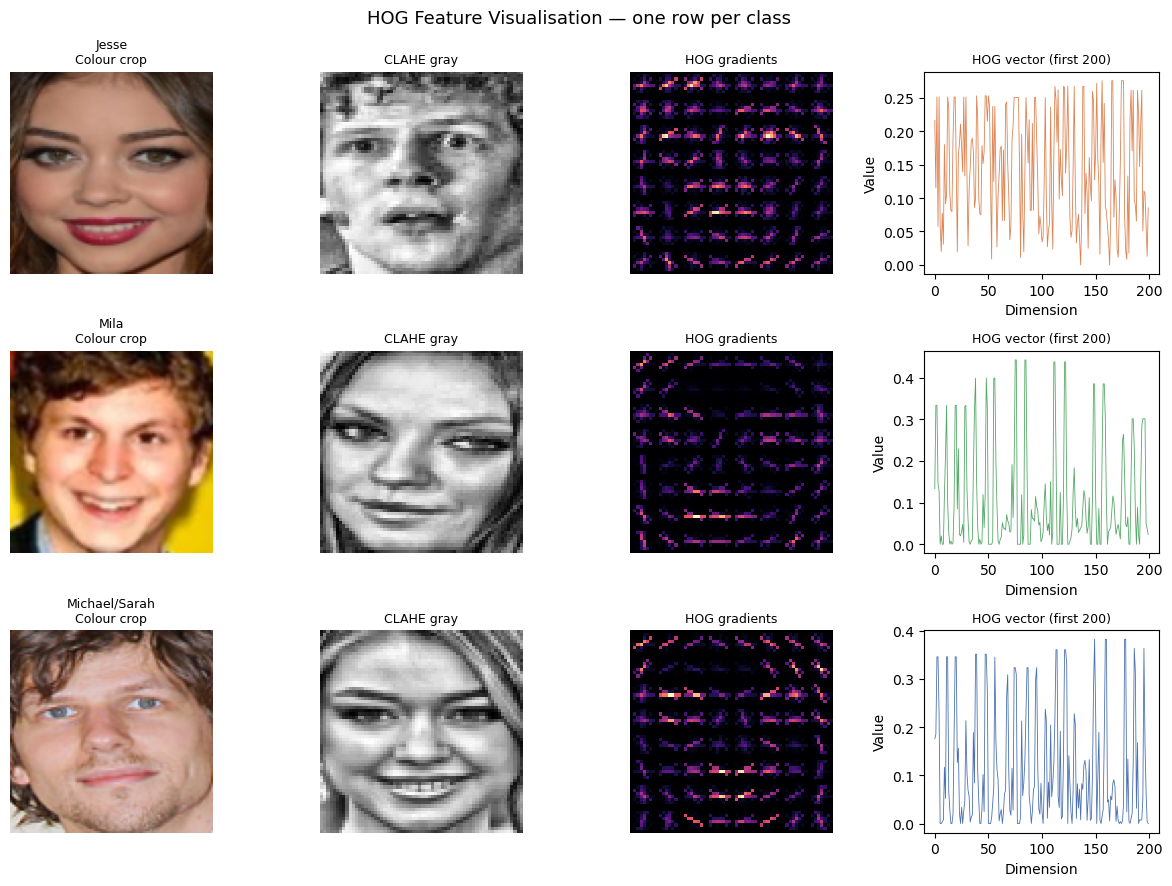

HOG vector length: 1764
Well-defined gradients around eyes, nose, and chin indicate
HOG is capturing meaningful facial structure.


In [6]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
class_order = [1, 2, 0]   # Jesse, Mila, Michael/Sarah

for row, cls in enumerate(class_order):
    idx = np.where(y_train == cls)[0][0]
    img_gray = X_train_gray[idx]

    feat, hog_img = hog(img_gray, **{**HOG_PARAMS, 'visualize': True})

    # Original colour crop
    axes[row, 0].imshow(np.clip(X_train_crops[train_idx[idx]] / 255.0, 0, 1))
    axes[row, 0].set_title(f'{CLASS_NAMES[cls]}\nColour crop', fontsize=9)
    axes[row, 0].axis('off')

    # Grayscale + CLAHE
    axes[row, 1].imshow(img_gray, cmap='gray')
    axes[row, 1].set_title('CLAHE gray', fontsize=9)
    axes[row, 1].axis('off')

    # HOG visualisation
    axes[row, 2].imshow(hog_img, cmap='magma')
    axes[row, 2].set_title('HOG gradients', fontsize=9)
    axes[row, 2].axis('off')

    # Feature vector (bar chart)
    axes[row, 3].plot(feat[:200], lw=0.6, color=CLASS_COLORS[cls])
    axes[row, 3].set_title('HOG vector (first 200)', fontsize=9)
    axes[row, 3].set_xlabel('Dimension')
    axes[row, 3].set_ylabel('Value')

fig.suptitle('HOG Feature Visualisation — one row per class', fontsize=13)
plt.tight_layout()
plt.show()

print(f"HOG vector length: {X_train_hog.shape[1]}")
print("Well-defined gradients around eyes, nose, and chin indicate")
print("HOG is capturing meaningful facial structure.")


### 1.4 t-SNE of HOG features

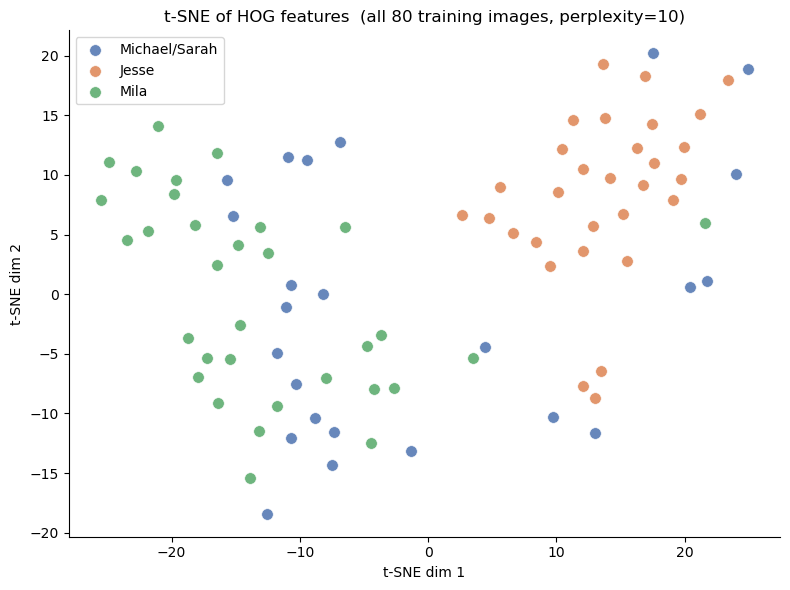


Interpretation guide
--------------------
Tight, well-separated clusters  → features are discriminative AND robust.
Jesse & Michael overlapping     → expected (visual similarity).
Scattered same-class points     → HOG is sensitive to pose/lighting variation.



In [7]:
# Use all training images (not just the train split) for a richer t-SNE
all_gray = batch_to_gray(train_X)
all_hog  = extract_hog(all_gray)

tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
coords_hog = tsne.fit_transform(all_hog)

fig, ax = plt.subplots(figsize=(8, 6))
for cls in sorted(np.unique(train_y)):
    mask = train_y == cls
    ax.scatter(
        coords_hog[mask, 0], coords_hog[mask, 1],
        c=CLASS_COLORS[cls], label=CLASS_NAMES[cls],
        s=70, alpha=0.85, edgecolors='white', linewidths=0.5
    )
ax.legend(fontsize=10)
ax.set_title('t-SNE of HOG features  (all 80 training images, perplexity=10)', fontsize=12)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("""
Interpretation guide
--------------------
Tight, well-separated clusters  → features are discriminative AND robust.
Jesse & Michael overlapping     → expected (visual similarity).
Scattered same-class points     → HOG is sensitive to pose/lighting variation.
""")


---
# 2. Features learned from data: PCA / Eigenfaces

**Principal Component Analysis (PCA)** finds the directions of maximum variance  
in the training data.  Applied to face images, these directions are called **eigenfaces**.

### Mathematical formulation

Given $N$ training images each flattened to a vector $x_i \in \mathbb{R}^D$:

1. Compute the **mean face**: $\bar{x} = \frac{1}{N}\sum_i x_i$  
2. Center: $\tilde{X} = X - \bar{x}$ (matrix of shape $N \times D$)  
3. Apply **SVD**: $\tilde{X} = U \Sigma V^T$  
   - Columns of $V$ are the eigenfaces (principal components)  
   - $\Sigma^2 / (N-1)$ gives the eigenvalues of the covariance matrix  
4. Project: $z_i = \tilde{x}_i V_p^T$ where $V_p$ keeps only the top $p$ rows

### Why mean-subtract?
PCA maximises variance from the **origin**, so without centering the first component  
just points toward the mean, wasting a component on global brightness.

### Non-zero eigenvalues
With $N=67$ training images and $D=4096$ pixels, the covariance matrix has rank  
at most $N-1 = 66$, so at most **66 non-zero eigenvalues**.  SVD handles this  
efficiently without forming the $D \times D$ covariance matrix.


### 2.1 Prepare flattened grayscale matrices

In [8]:
# Convert train crops (full set used for fitting PCA)
X_train_gray_full = batch_to_gray(X_train_crops)   # (N_train, 64, 64) uint8
X_val_gray_full   = batch_to_gray(X_val_crops)
X_test_gray_full  = batch_to_gray(test_X)

# Flatten  (N, H, W) -> (N, H*W)  and cast to float32
def flatten(imgs):
    return imgs.reshape(imgs.shape[0], -1).astype(np.float32)

X_train_flat = flatten(X_train_gray_full)   # (N_train, 4096)
X_val_flat   = flatten(X_val_gray_full)
X_test_flat  = flatten(X_test_gray_full)

print(f"Flat train : {X_train_flat.shape}")
print(f"Flat val   : {X_val_flat.shape}")
print(f"Flat test  : {X_test_flat.shape}")


Flat train : (73, 4096)
Flat val   : (13, 4096)
Flat test  : (1816, 4096)


### 2.2 Fit PCA on training data only

In [9]:
# Per-image normalisation before PCA:
# Subtract each image's own mean and divide by its std.
# This makes PCA focus on spatial structure (edges, facial layout)
# rather than global brightness differences between images.

def normalize_per_image(X, eps=1e-8):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + eps
    return (X - mean) / std

X_train_norm = normalize_per_image(X_train_flat)
X_val_norm   = normalize_per_image(X_val_flat)
X_test_norm  = normalize_per_image(X_test_flat)

# ── Fit SVD on training set only ────────────────────────────────────────────
# Using full SVD (full_matrices=False) is more memory-efficient than computing
# the D×D covariance matrix explicitly.  The singular values S relate to
# eigenvalues via:  eigenvalue_i = S_i^2 / (N - 1)
mean_face = X_train_norm.mean(axis=0)          # shape (D,)
X_centered = X_train_norm - mean_face          # shape (N_train, D)

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
# Vt : (min(N,D), D)  — rows are eigenfaces
# S  : (min(N,D),)    — singular values, descending

eigenvalues        = S**2 / (len(X_train_norm) - 1)
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var      = np.cumsum(explained_var_ratio)

n_nonzero = int((eigenvalues > 1e-10).sum())
print(f"Training samples        : {len(X_train_norm)}")
print(f"Feature dimension D     : {X_train_norm.shape[1]}")
print(f"Non-zero eigenvalues    : {n_nonzero}  (= N_train - 1 = {len(X_train_norm)-1})")
print()
for thr in [0.70, 0.80, 0.90, 0.95, 0.99]:
    k = int(np.searchsorted(cumulative_var, thr)) + 1
    print(f"  {thr*100:.0f}% variance explained by {k:3d} components")


Training samples        : 73
Feature dimension D     : 4096
Non-zero eigenvalues    : 72  (= N_train - 1 = 72)

  70% variance explained by  26 components
  80% variance explained by  35 components
  90% variance explained by  48 components
  95% variance explained by  58 components
  99% variance explained by  68 components


### 2.3 Scree plot — choose the number of components $p$

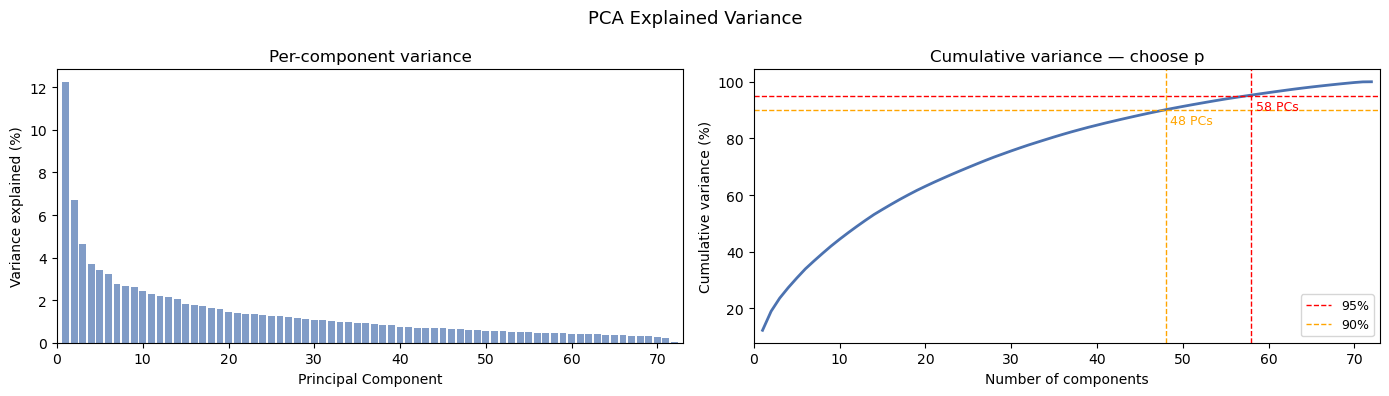

Selected p = 58  (95.3% variance explained)


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left: individual variance per component
ax1.bar(range(1, n_nonzero + 1), explained_var_ratio[:n_nonzero] * 100,
        color='#4C72B0', alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance explained (%)')
ax1.set_title('Per-component variance')
ax1.set_xlim(0, n_nonzero + 1)

# Right: cumulative variance with threshold markers
ax2.plot(range(1, n_nonzero + 1), cumulative_var[:n_nonzero] * 100,
         color='#4C72B0', lw=2)
ax2.axhline(95, color='red',    ls='--', lw=1, label='95%')
ax2.axhline(90, color='orange', ls='--', lw=1, label='90%')

# Mark crossings
for thr, color in [(0.90, 'orange'), (0.95, 'red')]:
    k = int(np.searchsorted(cumulative_var, thr)) + 1
    ax2.axvline(k, color=color, ls='--', lw=1)
    ax2.text(k + 0.5, thr * 100 - 5, f'{k} PCs', color=color, fontsize=9)

ax2.set_xlabel('Number of components')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Cumulative variance — choose p')
ax2.legend(fontsize=9)
ax2.set_xlim(0, n_nonzero + 1)

plt.suptitle('PCA Explained Variance', fontsize=13)
plt.tight_layout()
plt.show()

# ── Choose p ────────────────────────────────────────────────────────────────
# We target ~95% explained variance as a balance between compactness and
# information retention.  The exact value is read from the plot above.
P = int(np.searchsorted(cumulative_var, 0.95)) + 1
print(f"Selected p = {P}  ({cumulative_var[P-1]*100:.1f}% variance explained)")


### 2.4 Visualise eigenfaces

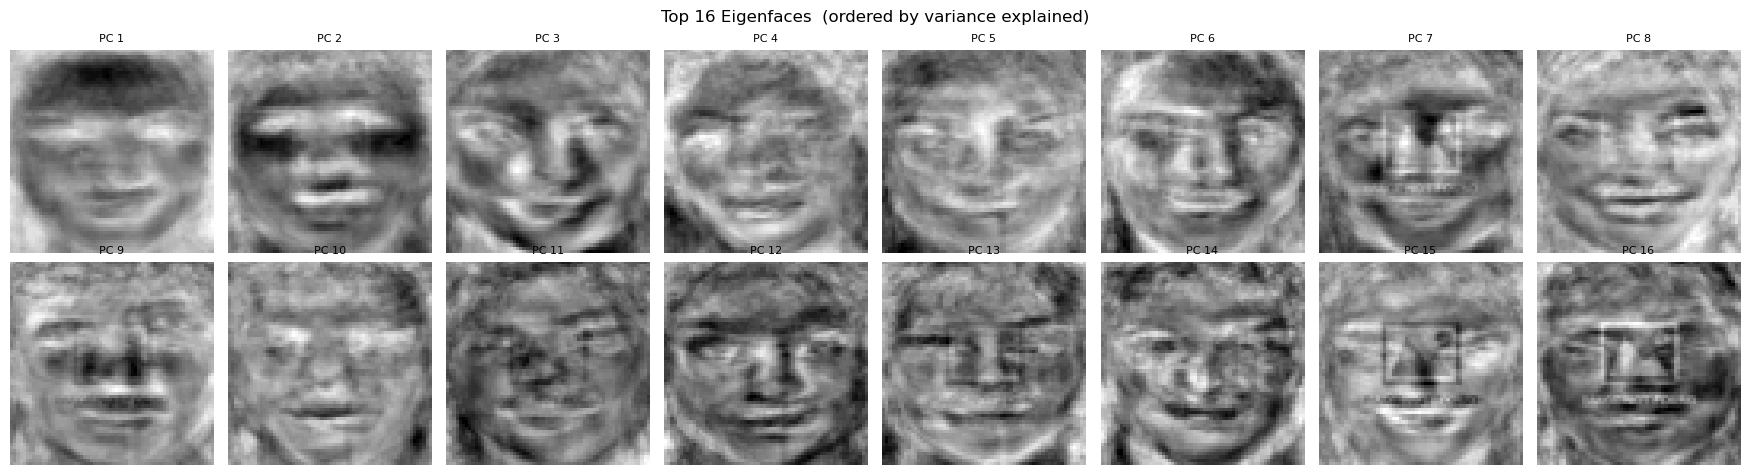


The first eigenfaces capture global variation:
  PC1 typically encodes overall brightness / lighting direction.
  PC2-4 capture large-scale pose or contrast gradients.
  Later PCs capture finer facial structure (eyes, mouth shape).



In [11]:
n_show = 16
ncols  = 8
nrows  = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.4 * nrows))
axes = axes.flatten()

for i in range(len(axes)):
    axes[i].axis('off')
    if i < n_show:
        ef = Vt[i].reshape(TARGET_SIZE[1], TARGET_SIZE[0])
        ef = (ef - ef.min()) / (ef.max() - ef.min() + 1e-8)
        axes[i].imshow(ef, cmap='gray')
        axes[i].set_title(f'PC {i+1}', fontsize=8)

fig.suptitle(f'Top {n_show} Eigenfaces  (ordered by variance explained)', fontsize=12)
plt.tight_layout()
plt.show()

print("""
The first eigenfaces capture global variation:
  PC1 typically encodes overall brightness / lighting direction.
  PC2-4 capture large-scale pose or contrast gradients.
  Later PCs capture finer facial structure (eyes, mouth shape).
""")


### 2.5 Reconstruction with increasing $p$

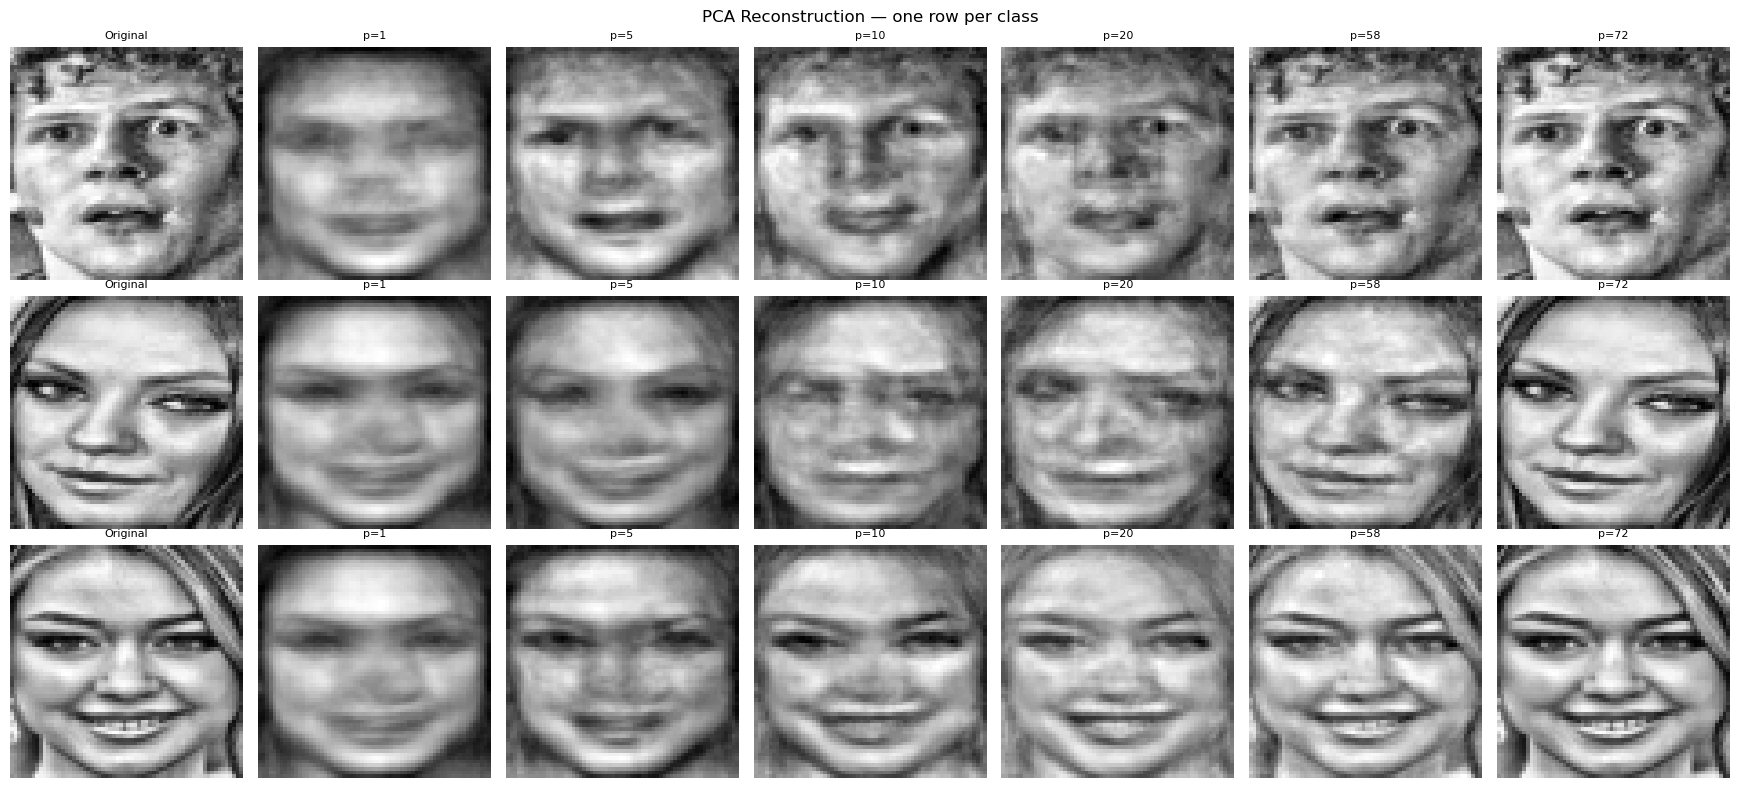

With p=58 components we already get a recognisable reconstruction.
Additional components refine fine details (texture, hair) but add less to identity.


In [12]:
# Show one image per class reconstructed with 1, 5, 10, 20, p, 66 components.
# This demonstrates how much information each extra eigenface adds.

p_values = [1, 5, 10, 20, P, n_nonzero]
p_values = sorted(set(p_values))   # deduplicate
n_cols   = len(p_values) + 1       # +1 for original

class_samples = [np.where(y_train == c)[0][0] for c in [1, 2, 0]]

fig, axes = plt.subplots(3, n_cols, figsize=(2.5 * n_cols, 8))

for row, sample_idx in enumerate(class_samples):
    cls   = y_train[sample_idx]
    x_raw = X_train_norm[sample_idx]
    x_cen = x_raw - mean_face

    # Column 0: original
    axes[row, 0].imshow(x_raw.reshape(TARGET_SIZE[1], TARGET_SIZE[0]), cmap='gray')
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].set_ylabel(CLASS_NAMES[cls], fontsize=9,
                             rotation=0, labelpad=60, va='center',
                             color=CLASS_COLORS[cls])
    axes[row, 0].axis('off')

    for col, k in enumerate(p_values, start=1):
        scores = x_cen @ Vt[:k].T                          # project
        recon  = mean_face + scores @ Vt[:k]               # reconstruct
        img    = recon.reshape(TARGET_SIZE[1], TARGET_SIZE[0])
        img    = np.clip((img - img.min()) / (img.max() - img.min() + 1e-8), 0, 1)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'p={k}', fontsize=8)
        axes[row, col].axis('off')

fig.suptitle('PCA Reconstruction — one row per class', fontsize=12)
plt.tight_layout()
plt.show()

print(f"With p={P} components we already get a recognisable reconstruction.")
print("Additional components refine fine details (texture, hair) but add less to identity.")


### 2.6 Project training images — first two principal components

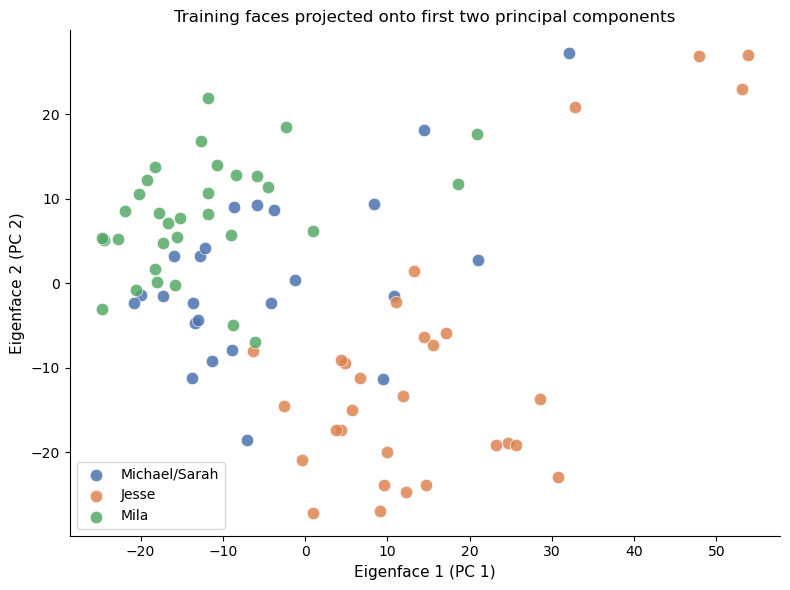

In [13]:
# Use ALL 80 training images for the scatter so every class has enough points.
all_norm    = normalize_per_image(flatten(batch_to_gray(train_X)))
all_centered = all_norm - mean_face
all_scores  = all_centered @ Vt[:2].T   # (80, 2)

fig, ax = plt.subplots(figsize=(8, 6))
for cls in sorted(np.unique(train_y)):
    mask = train_y == cls
    ax.scatter(
        all_scores[mask, 0], all_scores[mask, 1],
        c=CLASS_COLORS[cls], label=CLASS_NAMES[cls],
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )
ax.legend(fontsize=10)
ax.set_xlabel('Eigenface 1 (PC 1)', fontsize=11)
ax.set_ylabel('Eigenface 2 (PC 2)', fontsize=11)
ax.set_title('Training faces projected onto first two principal components', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 2.7 t-SNE of PCA features

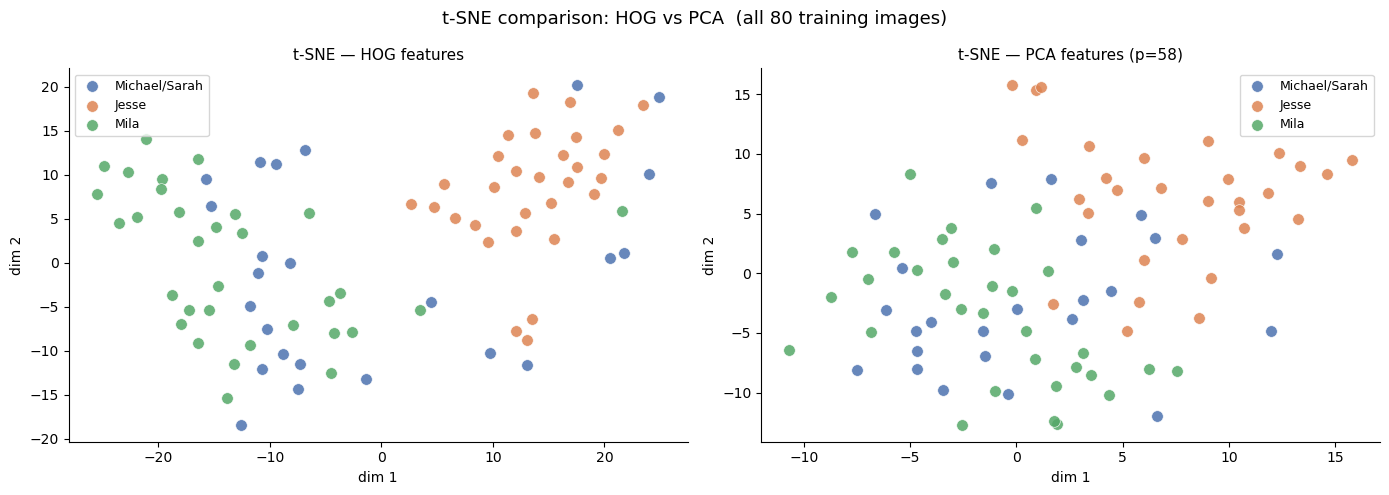

In [14]:
# Project ALL 80 training images onto the chosen P components
all_pca = all_centered @ Vt[:P].T    # (80, P)

tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
coords_pca = tsne.fit_transform(all_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coords, title in zip(
        axes,
        [coords_hog, coords_pca],
        ['HOG features', f'PCA features (p={P})']):
    for cls in sorted(np.unique(train_y)):
        mask = train_y == cls
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=CLASS_COLORS[cls], label=CLASS_NAMES[cls],
                   s=70, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.legend(fontsize=9)
    ax.set_title(f't-SNE — {title}', fontsize=11)
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('t-SNE comparison: HOG vs PCA  (all 80 training images)', fontsize=13)
plt.tight_layout()
plt.show()


### 2.8 Extract PCA features for all splits

In [15]:
# IMPORTANT: always use the SAME mean_face and Vt fitted on training data only.
# Applying it to val/test ensures no data leakage.

def pca_transform(X_flat, mean_face, Vt, p):
    """Project flat images onto top-p eigenfaces."""
    return (normalize_per_image(X_flat) - mean_face) @ Vt[:p].T

X_train_pca = pca_transform(X_train_flat, mean_face, Vt, P)
X_val_pca   = pca_transform(X_val_flat,   mean_face, Vt, P)
X_test_pca  = pca_transform(X_test_flat,  mean_face, Vt, P)

print(f"PCA train  : {X_train_pca.shape}  ({P} components)")
print(f"PCA val    : {X_val_pca.shape}")
print(f"PCA test   : {X_test_pca.shape}")


PCA train  : (73, 58)  (58 components)
PCA val    : (13, 58)
PCA test   : (1816, 58)


---
# 3. Classification

We evaluate multiple classifiers on both HOG and PCA features using a principled  
pipeline that always applies `StandardScaler` before any distance-based or  
margin-based classifier.

### Why StandardScaler?
HOG values are L2-normalised per block but can differ by orders of magnitude  
across cells.  PCA scores are orthogonal but not unit-variance (unless whitened).  
StandardScaler gives zero mean and unit variance per feature, which is required  
for SVM, LR, and MLP to converge well.

### Evaluation strategy
- **5-fold stratified cross-validation** on the training split.  
- Validation accuracy on the held-out split as a sanity check.  
- We *never* tune hyperparameters using the validation set.


### 3.0 Baseline — random classifier

In [16]:
class RandomClassifier:
    """Samples labels from the training class distribution."""

    def fit(self, X, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.priors_ = counts / counts.sum()
        return self

    def predict(self, X):
        np.random.seed(0)
        return np.random.choice(self.classes_, size=len(X), p=self.priors_)

rnd = RandomClassifier().fit(X_train_hog, y_train)
rnd_val = rnd.predict(X_val_hog)
print(f"Random classifier val accuracy: {accuracy_score(y_val, rnd_val)*100:.1f}%")
print("(Expected ~33% for uniform 3-class prior — this is the performance floor.)")


Random classifier val accuracy: 38.5%
(Expected ~33% for uniform 3-class prior — this is the performance floor.)


### 3.1 Benchmark: all classifiers on HOG and PCA

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    'RBF SVM':        SVC(kernel='rbf',  C=10, gamma='scale', random_state=42),
    'Linear SVM':     LinearSVC(C=1,     max_iter=5000, random_state=42),
    'Logistic Reg.':  LogisticRegression(C=1, max_iter=1000, solver='lbfgs', random_state=42),
    'LDA':            LDA(),
    'KNN (k=5)':      KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42),
    'MLP':            MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                    random_state=42),
}

def benchmark(X_tr, y_tr, X_va, y_va, feature_name):
    rows = []
    for name, clf in MODELS.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        cv_res = cross_validate(pipe, X_tr, y_tr, cv=cv,
                                scoring='accuracy', return_train_score=False)
        cv_mean = cv_res['test_score'].mean()
        cv_std  = cv_res['test_score'].std()

        pipe.fit(X_tr, y_tr)
        val_acc = accuracy_score(y_va, pipe.predict(X_va))

        rows.append({'Classifier': name,
                     'CV mean':    cv_mean,
                     'CV std':     cv_std,
                     'Val acc':    val_acc})
        print(f"  {name:<20s}  CV={cv_mean*100:5.1f}%±{cv_std*100:4.1f}%  "
              f"Val={val_acc*100:5.1f}%")
    return rows


print("=" * 60)
print("HOG features")
print("=" * 60)
hog_rows = benchmark(X_train_hog, y_train, X_val_hog, y_val, 'HOG')

print()
print("=" * 60)
print(f"PCA features  (p={P})")
print("=" * 60)
pca_rows = benchmark(X_train_pca, y_train, X_val_pca, y_val, 'PCA')


HOG features
  RBF SVM               CV= 89.0%± 9.7%  Val= 76.9%
  Linear SVM            CV= 86.4%± 8.7%  Val= 69.2%
  Logistic Reg.         CV= 89.0%± 7.2%  Val= 76.9%
  LDA                   CV= 74.0%±12.1%  Val= 84.6%
  KNN (k=5)             CV= 78.0%± 7.2%  Val= 84.6%
  Random Forest         CV= 85.0%± 8.0%  Val= 84.6%
  MLP                   CV= 84.9%±12.3%  Val= 69.2%

PCA features  (p=58)
  RBF SVM               CV= 57.2%± 9.4%  Val= 53.8%
  Linear SVM            CV= 50.6%± 5.9%  Val= 61.5%
  Logistic Reg.         CV= 50.8%± 4.0%  Val= 61.5%
  LDA                   CV= 39.8%±15.9%  Val= 69.2%
  KNN (k=5)             CV= 38.5%± 4.3%  Val= 53.8%
  Random Forest         CV= 72.6%± 4.3%  Val= 61.5%
  MLP                   CV= 42.3%±10.0%  Val= 53.8%


### 3.2 Visualise benchmark results

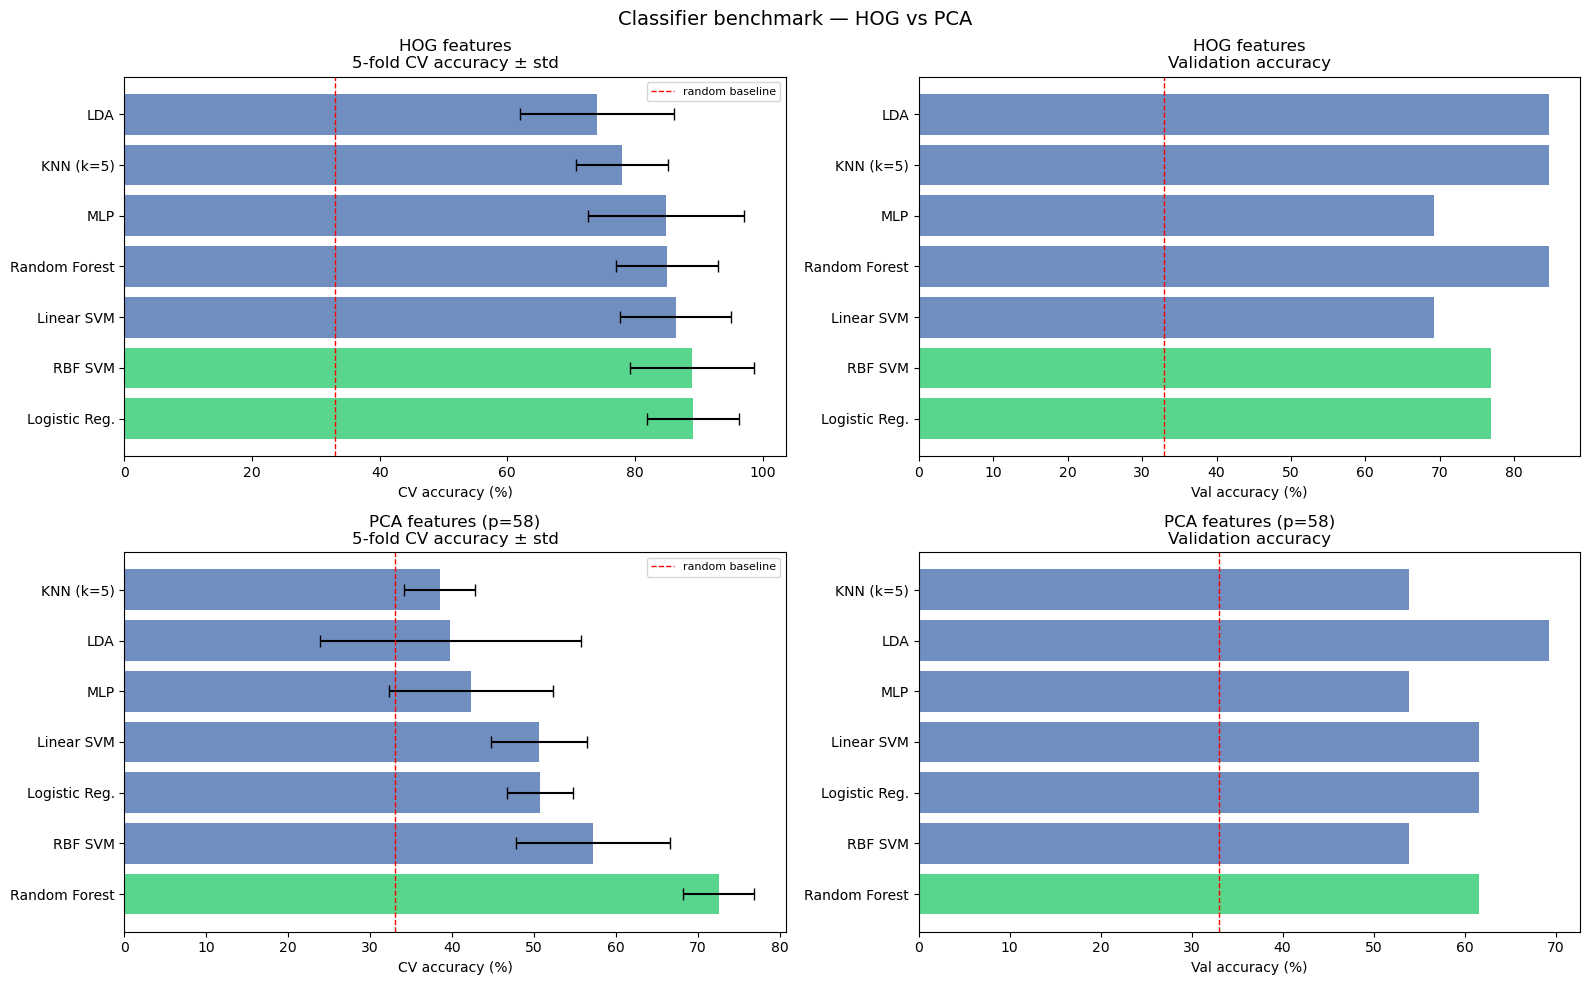

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_benchmark(rows, title, ax_left, ax_right):
    names    = [r['Classifier'] for r in rows]
    cv_means = [r['CV mean'] * 100 for r in rows]
    cv_stds  = [r['CV std']  * 100 for r in rows]
    val_accs = [r['Val acc'] * 100 for r in rows]
    y_pos    = range(len(names))

    # Sort by CV mean descending for readability
    order = np.argsort(cv_means)[::-1]
    names    = [names[i]    for i in order]
    cv_means = [cv_means[i] for i in order]
    cv_stds  = [cv_stds[i]  for i in order]
    val_accs = [val_accs[i] for i in order]

    colors = ['#2ecc71' if v >= max(cv_means) - 2 else '#4C72B0' for v in cv_means]

    ax_left.barh(y_pos, cv_means, xerr=cv_stds,
                 color=colors, alpha=0.8, capsize=4)
    ax_left.set_yticks(y_pos); ax_left.set_yticklabels(names)
    ax_left.set_xlabel('CV accuracy (%)')
    ax_left.set_title(f'{title}\n5-fold CV accuracy ± std')
    ax_left.axvline(33, color='red', ls='--', lw=1, label='random baseline')
    ax_left.legend(fontsize=8)

    ax_right.barh(y_pos, val_accs, color=colors, alpha=0.8)
    ax_right.set_yticks(y_pos); ax_right.set_yticklabels(names)
    ax_right.set_xlabel('Val accuracy (%)')
    ax_right.set_title(f'{title}\nValidation accuracy')
    ax_right.axvline(33, color='red', ls='--', lw=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_benchmark(hog_rows, 'HOG features',          axes[0, 0], axes[0, 1])
plot_benchmark(pca_rows, f'PCA features (p={P})', axes[1, 0], axes[1, 1])
plt.suptitle('Classifier benchmark — HOG vs PCA', fontsize=14)
plt.tight_layout()
plt.show()


### 3.3 Hyperparameter tuning — best HOG classifier

In [20]:
# Tune the best-performing HOG classifier (typically RBF SVM) via GridSearchCV.
# Grid is searched on the training split only — val set is never seen.

hog_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', probability=True, random_state=42)),
])

param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01],
}

grid_hog = GridSearchCV(
    hog_pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_hog.fit(X_train_hog, y_train)

print(f"Best params : {grid_hog.best_params_}")
print(f"Best CV acc : {grid_hog.best_score_*100:.1f}%")
print(f"Val acc     : {accuracy_score(y_val, grid_hog.predict(X_val_hog))*100:.1f}%")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'svm__C': 10, 'svm__gamma': 'scale'}
Best CV acc : 89.0%
Val acc     : 76.9%


### 3.4 Hyperparameter tuning — best PCA classifier

In [21]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', probability=True, random_state=42)),
])

grid_pca = GridSearchCV(
    pca_pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_pca.fit(X_train_pca, y_train)

print(f"Best params : {grid_pca.best_params_}")
print(f"Best CV acc : {grid_pca.best_score_*100:.1f}%")
print(f"Val acc     : {accuracy_score(y_val, grid_pca.predict(X_val_pca))*100:.1f}%")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params : {'svm__C': 10, 'svm__gamma': 0.01}
Best CV acc : 57.3%
Val acc     : 69.2%


### 3.5 Confusion matrices & classification reports


HOG + RBF SVM  —  Val accuracy: 76.9%
               precision    recall  f1-score   support

Michael/Sarah       1.00      0.50      0.67         4
        Jesse       0.67      1.00      0.80         4
         Mila       0.80      0.80      0.80         5

     accuracy                           0.77        13
    macro avg       0.82      0.77      0.76        13
 weighted avg       0.82      0.77      0.76        13



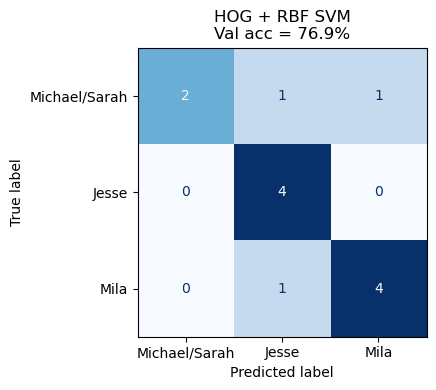


PCA (p=58) + RBF SVM  —  Val accuracy: 69.2%
               precision    recall  f1-score   support

Michael/Sarah       0.50      0.75      0.60         4
        Jesse       1.00      0.50      0.67         4
         Mila       0.80      0.80      0.80         5

     accuracy                           0.69        13
    macro avg       0.77      0.68      0.69        13
 weighted avg       0.77      0.69      0.70        13



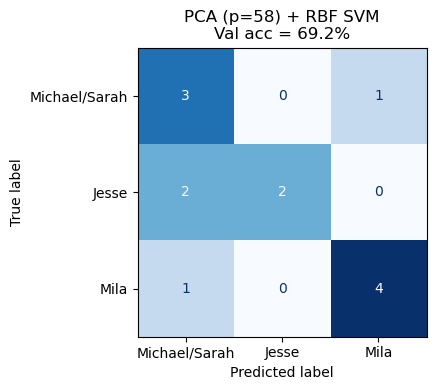

In [22]:
target_names = list(CLASS_NAMES.values())   # ['Michael/Sarah', 'Jesse', 'Mila']

for label, model, X_val_feat in [
        ('HOG + RBF SVM', grid_hog, X_val_hog),
        (f'PCA (p={P}) + RBF SVM', grid_pca, X_val_pca),
]:
    y_pred = model.predict(X_val_feat)
    acc    = accuracy_score(y_val, y_pred)
    print(f"\n{'='*55}")
    print(f"{label}  —  Val accuracy: {acc*100:.1f}%")
    print('='*55)
    print(classification_report(y_val, y_pred, target_names=target_names))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=target_names,
        ax=ax, colorbar=False, cmap='Blues',
    )
    ax.set_title(f'{label}\nVal acc = {acc*100:.1f}%')
    plt.tight_layout()
    plt.show()


### 3.6 Validate on lookalike images (Michael Cera & Sarah Hyland)

In [23]:
# Class 0 = lookalikes (Michael Cera ~ Jesse, Sarah Hyland ~ Mila).
# A good classifier should return class 0 (neither) for these.
# Confusion with class 1 or 2 means the classifier overfits to visual similarity.

lookalike_mask = y_val == 0

for label, model, X_val_feat in [
        ('HOG', grid_hog, X_val_hog),
        (f'PCA p={P}', grid_pca, X_val_pca),
]:
    if lookalike_mask.sum() == 0:
        print(f"{label}: no lookalike samples in validation split (try a different seed).")
        continue
    y_pred_la = model.predict(X_val_feat[lookalike_mask])
    acc_la    = accuracy_score(y_val[lookalike_mask], y_pred_la)
    print(f"{label:20s}  lookalike accuracy: {acc_la*100:.0f}%  "
          f"({lookalike_mask.sum()} samples)")
    print(f"  Predictions: {[CLASS_NAMES[p] for p in y_pred_la]}")
    print()


HOG                   lookalike accuracy: 50%  (4 samples)
  Predictions: ['Mila', 'Michael/Sarah', 'Michael/Sarah', 'Jesse']

PCA p=58              lookalike accuracy: 75%  (4 samples)
  Predictions: ['Michael/Sarah', 'Michael/Sarah', 'Michael/Sarah', 'Mila']



### 3.7 Summary table

In [24]:
print(f"{'Classifier':<22} {'HOG CV':>8} {'HOG Val':>8} {'PCA CV':>8} {'PCA Val':>8}")
print('-' * 58)

hog_by_name = {r['Classifier']: r for r in hog_rows}
pca_by_name = {r['Classifier']: r for r in pca_rows}

for name in MODELS:
    h = hog_by_name.get(name, {})
    p = pca_by_name.get(name, {})
    print(f"{name:<22} "
          f"{h.get('CV mean', 0)*100:7.1f}% "
          f"{h.get('Val acc', 0)*100:7.1f}% "
          f"{p.get('CV mean', 0)*100:7.1f}% "
          f"{p.get('Val acc', 0)*100:7.1f}%")

print()
print(f"Best HOG : CV={max(r['CV mean'] for r in hog_rows)*100:.1f}%  "
      f"Val={max(r['Val acc'] for r in hog_rows)*100:.1f}%")
print(f"Best PCA : CV={max(r['CV mean'] for r in pca_rows)*100:.1f}%  "
      f"Val={max(r['Val acc'] for r in pca_rows)*100:.1f}%")


Classifier               HOG CV  HOG Val   PCA CV  PCA Val
----------------------------------------------------------
RBF SVM                   89.0%    76.9%    57.2%    53.8%
Linear SVM                86.4%    69.2%    50.6%    61.5%
Logistic Reg.             89.0%    76.9%    50.8%    61.5%
LDA                       74.0%    84.6%    39.8%    69.2%
KNN (k=5)                 78.0%    84.6%    38.5%    53.8%
Random Forest             85.0%    84.6%    72.6%    61.5%
MLP                       84.9%    69.2%    42.3%    53.8%

Best HOG : CV=89.0%  Val=84.6%
Best PCA : CV=72.6%  Val=69.2%


---
# 4. Test predictions & submission

Use whichever model scored highest on cross-validation.  
Replace `best_model` and `X_test_feat` accordingly.


In [25]:
# ── Pick best model ──────────────────────────────────────────────────────────
best_hog_cv = max(r['CV mean'] for r in hog_rows)
best_pca_cv = max(r['CV mean'] for r in pca_rows)

if best_hog_cv >= best_pca_cv:
    best_model    = grid_hog
    X_test_feat   = X_test_hog
    best_feat_name = 'HOG'
else:
    best_model    = grid_pca
    X_test_feat   = X_test_pca
    best_feat_name = f'PCA (p={P})'

print(f"Using: {best_feat_name}  (CV={max(best_hog_cv, best_pca_cv)*100:.1f}%)")

# ── Generate test predictions ─────────────────────────────────────────────
import pandas as pd
test_df = pd.read_csv('datasets/test_set.csv', index_col=0)
test_df.index = test_df.index.rename('id')

test_predictions = best_model.predict(X_test_feat)

print("Test prediction distribution:")
for cls, cnt in zip(*np.unique(test_predictions, return_counts=True)):
    print(f"  {CLASS_NAMES[cls]}: {cnt} ({cnt/len(test_predictions)*100:.1f}%)")

submission = test_df.drop('img', axis=1, errors='ignore').copy()
submission['class'] = test_predictions
submission.to_csv('submission.csv')
print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()


Using: HOG  (CV=89.0%)
Test prediction distribution:
  Michael/Sarah: 603 (33.2%)
  Jesse: 600 (33.0%)
  Mila: 613 (33.8%)
Saved 1816 predictions to submission.csv


,class
id,
0,1
1,0
2,0
3,1
4,1


---
# 5. Discussion

### HOG vs PCA — qualitative comparison

| Property | HOG | PCA |
|----------|-----|-----|
| **Type** | Handcrafted | Learned from data |
| **Invariance** | Mild lighting (block normalisation) | Lighting (captured by first PCs, then discarded) |
| **Discriminability** | High — directly encodes edge structure | Moderate — first PCs capture pose/lighting, not identity |
| **Sample efficiency** | Does not need training data | Needs enough samples to estimate meaningful components |
| **Dimensionality** | Fixed at 1764 | Tunable: p chosen by explained variance |
| **Interpretability** | HOG image shows gradient directions | Eigenfaces are visualisable but abstract |

### When does each fail?
- **HOG** fails under large pose variation (>30°) because gradient patterns shift significantly.  
  It also fails when the face crop is incorrect (e.g. detecting a shirt instead of a face).
- **PCA** fails when the test-set faces look different from training (different lighting direction,  
  occlusions) because the eigenspace was computed from training images only.  
  With only 66 non-zero components, it also loses fine discriminative detail.

### What would we improve with more time?
1. **Face alignment** (landmark-based crop) so HOG and PCA always operate on the same  
   canonical position — currently, head tilt and scale variation are noise.
2. **Deep features** (FaceNet / ArcFace embeddings) — these are pre-trained on millions of  
   faces and encode identity far more robustly than HOG or PCA.
3. **Data augmentation** during training (horizontal flip, small rotations, brightness jitter)  
   to make the classifier more robust with only 80 training images.
4. **Ensemble** of HOG-SVM and PCA-SVM — predictions often disagree on borderline cases  
   and majority vote can recover the correct label.
